<a href="https://colab.research.google.com/github/PurbitaS/Biopython/blob/main/Biopythoning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## What is Biopython?


All information sourced from Biopython Tutorial and Cookbook (https://biopython.org/docs/latest/Tutorial/index.html)

Biopython is a collection of freely available Python (https://www.python.org) modules for computational molecular biology. It is a set of libraries to provide the ability to deal with “things” of interest to biologists working on the computer. Since its inception in 2000, Biopython has been continuously developed and maintained by a large group of volunteers worldwide.

Biopython includes parsers for various bioinformatics file formats (BLAST, Clustalw, FASTA, Genbank, …), access to online services (NCBI, Expasy, …), a standard sequence class, sequence alignment and motif analysis tools, clustering algorithms, a module for structural biology, and a module for phylogenetics analysis.

Biopython's job is to make your job easier as a programmer, i.e., make you happy!

One of the functionalities of Biopython includes integration with BioSQL, a sequence database schema also supported by the BioPerl and BioJava projects.

In [3]:
%pip install pandas numpy matplotlib

import pandas  as pd
import numpy as np
import matplotlib as pyplt
import seaborn as sns
import sklearn

In [4]:
!pip install biopython

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 34.4 MB/s eta 0:00:00


In [5]:
import Bio
print(Bio.__version__)

1.85


***We will be using Lady Slipper Orchid as the working example henceforth similar to the biopython cookbook***

**Parsing sequence file formats**

File parsing simplifies complex data into manageable parts. It helps systems recognize and use the data.

Simple FASTA and GenBank parsing examples using LS Orchid are shown below   
(We will discuss SeqIO soon!)

In [ ]:
#fasta parsing

from Bio import SeqIO
for seq_record in SeqIO.parse("/content/ls_orchid.fasta", "fasta"):
    print(seq_record.id)
    print(repr(seq_record.seq))
    print(len(seq_record))

gi|2765658|emb|Z78533.1|CIZ78533
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGG...CGC')
740
gi|2765657|emb|Z78532.1|CCZ78532
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAACAG...GGC')
753
gi|2765656|emb|Z78531.1|CFZ78531
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGCAG...TAA')
748
gi|2765655|emb|Z78530.1|CMZ78530
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAAACAACAT...CAT')
744
gi|2765654|emb|Z78529.1|CLZ78529
Seq('ACGGCGAGCTGCCGAAGGACATTGTTGAGACAGCAGAATATACGATTGAGTGAA...AAA')
733
gi|2765652|emb|Z78527.1|CYZ78527
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...CCC')
718
gi|2765651|emb|Z78526.1|CGZ78526
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...TGT')
730
gi|2765650|emb|Z78525.1|CAZ78525
Seq('TGTTGAGATAGCAGAATATACATCGAGTGAATCCGGAGGACCTGTGGTTATTCG...GCA')
704
gi|2765649|emb|Z78524.1|CFZ78524
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGATAGTAG...AGC')
740
gi|2765648|emb|Z78523.1|CHZ78523
Seq('CGTAACCAGGTTTCCGT

In [ ]:
#genbank

from Bio import SeqIO
for seq_record in SeqIO.parse("/content/ls_orchid.gbk", "genbank"):
    print(seq_record.id)            #shorter id compared to fasta
    print(repr(seq_record.seq))
    print(len(seq_record))

Z78533.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGATGAGACCGTGG...CGC')
740
Z78532.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAACAG...GGC')
753
Z78531.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGCAG...TAA')
748
Z78530.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAAACAACAT...CAT')
744
Z78529.1
Seq('ACGGCGAGCTGCCGAAGGACATTGTTGAGACAGCAGAATATACGATTGAGTGAA...AAA')
733
Z78527.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...CCC')
718
Z78526.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAG...TGT')
730
Z78525.1
Seq('TGTTGAGATAGCAGAATATACATCGAGTGAATCCGGAGGACCTGTGGTTATTCG...GCA')
704
Z78524.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGATAGTAG...AGC')
740
Z78523.1
Seq('CGTAACCAGGTTTCCGTAGGTGAACCTGCGGCAGGATCATTGTTGAGACAGCAG...AAG')
709
Z78522.1
Seq('CGTAACAAGGTTTCCGTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGCAG...GAG')
700
Z78521.1
Seq('GTAGGTGAACCTGCGGAAGGATCATTGTTGAGACAGTAGAATATATGATCGAGT...ACC')
726
Z78520.1
Seq('CGTAACAAGGTTTC

**Connecting with biological databases**

One of the very common things that we need to do in bioinformatics is extract information from biological databases. It can be quite tedious to access these databases manually, especially if we have a lot of repetitive work to do.   
Biopython attempts to save us time and energy by making some on-line databases available from Python scripts. Currently, Biopython has code to extract information from the following databases:

- **Entrez (and PubMed)** from the NCBI – See Chapter Accessing NCBI’s Entrez databases.

- **ExPASy** – See Chapter Swiss-Prot and ExPASy.

- **SCOP** – See the Bio.SCOP.search() function.

The code in these modules basically makes it easy to write Python code that interact with the CGI scripts on these pages, so that you can get results in an easy to deal with format. In some cases, the results can be tightly integrated with the Biopython parsers to make it even easier to extract information.


** A *CGI script*, or Common Gateway Interface script, is an executable program residing on a web server that enables the server to interact with external applications to generate dynamic content for web pages. When a web browser sends a request to a web server that invokes a CGI script, the server executes the script and sends its output back to the browser.

## Seq aka Sequence objects

Sequences are essentially strings of letters like *AGTACACTGGT*, which seems very natural since this is the most common way that sequences are seen in biological file formats.


### - Biologically relevant methods



The most important difference between *Seq* objects and standard Python strings is they have different methods. Although the *Seq* object supports many of the same methods as a plain string, its *translate()* method differs by doing biological translation, and there are also additional biologically relevant methods like *reverse_complement()*.

Note - *Bio.SeqUtils* module has several GC functions already built in. Eg: *.gc_fraction()* that calculates GC content.

In [9]:
from Bio.Seq import Seq           #Seq is an object created using the following sequence

#complement and reverse complement - functions of biopython
my_seq = Seq("AGTACACTGGTACGGACACGT")
my_seq
print("Sequence :", my_seq)

my_seq.complement()
print("Complementary sequence: ", my_seq.complement())

my_seq.reverse_complement()
print("Reverse complementary sequence: ", my_seq.reverse_complement())

#reversing a string - Python function
my_seq [::-1]
print("Sequence in reverse: ", my_seq [::-1])

Sequence : AGTACACTGGTACGGACACGT
Complementary sequence:  TCATGTGACCATGCCTGTGCA
Reverse complementary sequence:  ACGTGTCCGTACCAGTGTACT
Sequence in reverse:  TGCACAGGCATGGTCACATGA


In [ ]:
from Bio.Seq import Seq

my_seq = Seq("GCGATCGATGGGCCTATATAGGATCGAAAATCGC")

print("DNA sequence", my_seq)
print("Sequence Length", len(my_seq))
print("G count", my_seq.count("G"))
print("A count", my_seq.count("A"))
print("GC content", (my_seq.count("G") + my_seq.count("C")) / len(my_seq) * 100, "%")

# Seq objecct contains some biologically relevant methods

print("Translated sequence", my_seq.translate())
print("Reverse complement", my_seq.reverse_complement())

DNA sequence GCGATCGATGGGCCTATATAGGATCGAAAATCGC
Sequence Length 34
G count 10
A count 10
GC content 50.0 %
Translated sequence AIDGPI*DRKS
Reverse complement GCGATTTTCGATCCTATATAGGCCCATCGATCGC


### - Functions similar to Python

Much like Python strings, *Seq* object can be used for
(a) getting the length, (b) accessing elements, (c) iterate over elements, (d) changing case

In [6]:
# (a) getting the length, (b) accessing elements, (c) iterate over elements, (d) changing case

from Bio.Seq import Seq
seqn = Seq("GAgTacGgtC")

print("Lowercase", seqn.lower())
print("Uppercase", seqn.upper())

for index, letter in enumerate(seqn):
    print("%i %s" % (index, letter))
print("Length", len(seqn))

print(seqn[0])    # first letter
print(seqn[2])    # third letter
print(seqn[4])    # fifth letter
print(seqn[-1])   # last letter

from Bio.SeqUtils import gc_fraction
print("GC content ", gc_fraction(seqn))

Lowercase gagtacggtc
Uppercase GAGTACGGTC
0 G
1 A
2 g
3 T
4 a
5 c
6 G
7 g
8 t
9 C
Length 10
G
g
a
C
GC content  0.6


#### - Slicing a sequence

   - *Seq* objects follow the usual indexing conventions for Python strings, with the first element of the sequence numbered 0. While slicing the first item is included (i.e. 4 in this case) and the last is excluded (12 in this case).

   - Also like a Python string, we can do slices with a start, stop and stride/step (the step size, which defaults to one). Step means that after the first character, it will select the character at the next step count. Eg: for step = 3, every 3rd character will be chosen.

   - Use of a -1 stride to reverse the string.

In [ ]:
# Slicing a sequence

my_seq = Seq("GATCGATGGGCCTATATAGGATCGAAAATCGC")
print("Sequence", my_seq)
print("Sliced sequence", my_seq[4:12])
print(my_seq[4:9:])       #start and stop
print(my_seq[2::3])       #start and step - starts at index 2 and prints every 3rd character
print("Reverse", my_seq[::-1])

Sequence GATCGATGGGCCTATATAGGATCGAAAATCGC
Sliced sequence GATGGGCC
GATGG
TAGCTAAGAC
Reverse CGCTAAAAGCTAGGATATATCCGGGTAGCTAG


#### - Concatenating or adding sequences

Two sequences can be concatenated similar to strings using
   - '+' sign
   - .join()

In [ ]:
seq1 = "AGAGCTAG"
seq2 = "CCCGGG"
print("Sequences", seq1, seq2)
print("Concatenated", seq1+seq2)

Sequences AGAGCTAG CCCGGG
Concatenated AGAGCTAGCCCGGG


In [ ]:
# using a for loop for multiple sequence concatenation

seq_list = [Seq("GGGAAA"), Seq("CCTA"), Seq("GCGTCT"), Seq("AAAA")]
print("Sequence list", seq_list)
concat = Seq("")
for seq in seq_list:
  concat += seq
print("Concatenated sequence", concat)



Sequence list [Seq('GGGAAA'), Seq('CCTA'), Seq('GCGTCT'), Seq('AAAA')]
Concatenated sequence GGGAAACCTAGCGTCTAAAA


In [ ]:
# Using .join method for concatenation

seq_list = [Seq("GGGAAA"), Seq("CCTA"), Seq("GCGTCT"), Seq("AAAA")]
print("Sequence list", seq_list)
concat_seq = Seq("")
print("Concatenated sequence", concat_seq.join(seq_list))

Sequence list [Seq('GGGAAA'), Seq('CCTA'), Seq('GCGTCT'), Seq('AAAA')]
Concatenated sequence GGGAAACCTAGCGTCTAAAA


### Transcription

In biology, transcription takes place on the *template strand (3' - 5')* by doing a reverse complement to produce *mRNA (5' - 3')*.   
In contrast, in biopython (or bioinformatics in general), we typically work directly with the *coding strand (5' - 3')* because this means we can get the *mRNA sequence (5' - 3')* just by switching **T -> U**

- The Seq object includes a built-in method **transcribe()** to transcribe a sequence to its corresponding mRNA by a simple T -> U substitution.
- The Seq object also includes a back-transcription method **back_transcribe()** for reverse transcribing the mRNA to the coding strand of the DNA. Again, this is a simple U -> T substitution

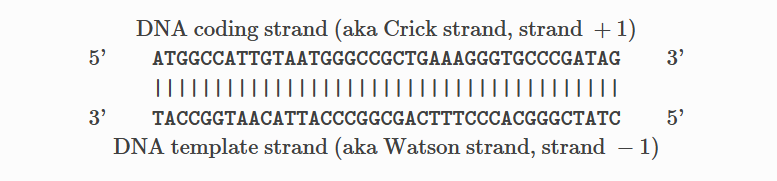

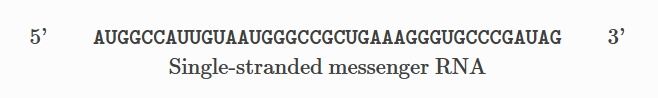

In [16]:
#transcription

from Bio.Seq import Seq
coding_dna = Seq("ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG")
print('Coding strand:', coding_dna)
template_dna = coding_dna.reverse_complement()
print('Template strand:', template_dna)

#transcribe() method using coding strand
messenger_rna = coding_dna.transcribe()
print('Messenger RNA:', messenger_rna)

#transcribe() method using template strand  makes it a two step process
m_rna = template_dna.reverse_complement().transcribe()
print('Messenger RNA', m_rna)

#reverse transcription / back transcription

reverse_dna = messenger_rna.back_transcribe()
print('Reverse DNA:', reverse_dna)

Coding strand: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG
Template strand: CTATCGGGCACCCTTTCAGCGGCCCATTACAATGGCCAT
Messenger RNA: AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
Messenger RNA AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
Reverse DNA: ATGGCCATTGTAATGGGCCGCTGAAAGGGTGCCCGATAG


### Translation

Translation of a messenger RNA sequence to produce a protein sequence takes place by using the **translate()** method.

In [19]:
#translate

from Bio.Seq import Seq
messenger_rna = Seq("AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG")
print('mRNA seq:', messenger_rna)
protein = messenger_rna.translate()
print('Protein seq:', protein)

mRNA seq: AUGGCCAUUGUAAUGGGCCGCUGAAAGGGUGCCCGAUAG
Protein seq: MAIVMGR*KGAR*


Notice that in the above protein sequence, in addition to the end stop character (*), there is an internal stop as well.

The translation tables available in Biopython are based on those from the NCBI. By default, translation will use the standard genetic code (NCBI table id 1).   
Eg: If we are dealing with a mitochondrial sequence, we need to tell the translation function to use the relevant genetic code (table id 2).

## Practice code

1. Read a DNA Sequence from a File

.> **from Bio import SeqIO**

imports the **SeqIO module** from the **Biopython library**. This module provides functions for reading (parsing) and writing biological sequence files (like FASTA, GenBank, etc.) as objects in Python, making it easy to work with sequence data in many common bioinformatics formats

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
from Bio import SeqIO

for record in SeqIO.parse("rcsb_pdb_6E3Y.fasta", "fasta"):
    print("\nID:", record.id)
    print("Description:", record.description)
    print("Sequence:", record.seq)


ID: 6E3Y_1|Chain
Description: 6E3Y_1|Chain A[auth P]|Calcitonin gene-related peptide 1|Homo sapiens (9606)
Sequence: ACDTATCVTHRLAGLLSRSGGVVKNNFVPTNVGSKAFX

ID: 6E3Y_2|Chain
Description: 6E3Y_2|Chain B[auth N]|Nanobody 35|Lama glama (9844)
Sequence: QVQLQESGGGLVQPGGSLRLSCAASGFTFSNYKMNWVRQAPGKGLEWVSDISQSGASISYTGSVKGRFTISRDNAKNTLYLQMNSLKPEDTAVYYCARCPAPFTRDCFDVTSTTYAYRGQGTQVTVSSHHHHHHEPEA

ID: 6E3Y_3|Chain
Description: 6E3Y_3|Chain C[auth A]|Guanine nucleotide-binding protein G(s) subunit alpha isoforms short|Homo sapiens (9606)
Sequence: MGCLGNSKTEDQRNEEKAQREANKKIEKQLQKDKQVYRATHRLLLLGAGESGKNTIVKQMRILHVNGFNGEGGEEDPQAARSNSDGEKATKVQDIKNNLKEAIETIVAAMSNLVPPVELANPENQFRVDYILSVMNVPDFDFPPEFYEHAKALWEDEGVRACYERSNEYQLIDCAQYFLDKIDVIKQADYVPSDQDLLRCRVLTSGIFETKFQVDKVNFHMFDVGAQRDERRKWIQCFNDVTAIIFVVASSSYNMVIREDNQTNRLQAALKLFDSIWNNKWLRDTSVILFLNKQDLLAEKVLAGKSKIEDYFPEFARYTTPEDATPEPGEDPRVTRAKYFIRDEFLRISTASGDGRHYCYPHFTCAVDTENIRRVFNDCRDIIQRMHLRQYELL

ID: 6E3Y_4|Chain
Description: 6E3Y_4|Chain D[auth B]|Guanine 